# Data Pipeline, Cleaning, and EDA - E-Commerce Nowcasting (Netherlands)

**Project:** Forecasting E-Commerce Sector Demand Using Public Search Trends and Macroeconomic Indicators

This notebook pulls monthly Dutch e-commerce turnover (Eurostat, target variable), HICP inflation (Eurostat, macroeconomic feature), and Google Trends search interest for "online shopping" (leading indicator), then cleans, merges, and engineers lag features for modeling.

https://github.com/suvidhya-venkanna/ecommerce-nowcasting

1. **Date-range bug (the most important fix):** Eurostat data was previously pulled with no start-date filter, while Google Trends was limited to `START_DATE` (2018 onward). After an outer merge, this left roughly 27 years of rows with `search_index = NaN`, which the `.bfill()` step then silently filled with the single earliest real 2018 value - fabricating decades of flat-line "search interest" data. The merge step now explicitly restricts the dataset to `START_DATE` onward *before* imputation.
2. **Missing lag features:** the markdown claimed lag features at t-1, t-3, and t-12, but the code only created a single `lag1` column (and on the target, not the search index). This is now implemented fully: `ecommerce_turnover_lag1/3/12` and `search_index_lag1/3/12`.
3. **Export path bug:** the final cleaned/processed dataset was being saved into `data/raw/`, which should only contain untouched API pulls. It now saves to `data/processed/`, and the raw API responses are saved separately to `data/raw/` right after collection, for reproducibility.
4. **EDA scale mismatch:** the turnover index (roughly 80-160) and the Google Trends search index (0-100) were being plotted on the same shared axis in a couple of charts, which is visually misleading since they are not comparable scales. Fixed with a secondary axis / rescaling where relevant.



In [6]:
!pip install eurostat pytrends

In [9]:
# --- Section 1: Configuration & Imports ---
import pandas as pd
import numpy as np
import eurostat
import xgboost as xgb
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_percentage_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from sklearn.preprocessing import MinMaxScaler
from pytrends.request import TrendReq
from datetime import datetime
import matplotlib.pyplot as plt
import seaborn as sns
import os



# Create folder structure
os.makedirs('data/raw', exist_ok=True)
os.makedirs('data/processed', exist_ok=True)
TODAY = datetime.today().strftime('%Y-%m-%d')
START_DATE = '2018-01-01'  # Google Trends only supports a few years of reliable history;
                            # this is the earliest date all three sources can be fairly compared from.

# --- Section 2: Data Acquisition ---
def fetch_production_data():
    """Fetches Eurostat and Google Trends data."""
    # Google Trends
    pytrends = TrendReq(hl='en-US', tz=360)
    pytrends.build_payload(["online shopping"], timeframe=f'{START_DATE} {TODAY}', geo='NL')
    trends = pytrends.interest_over_time().reset_index().rename(columns={'date': 'Date', 'online shopping': 'search_index'})

    # Eurostat Turnover
    df_raw = eurostat.get_data_df('sts_trtu_m')
    df_t = df_raw[(df_raw['nace_r2'] == 'G4791') & (df_raw['geo\\TIME_PERIOD'] == 'NL') & (df_raw['s_adj'] == 'SCA')]

    # Eurostat HICP
    hicp_raw = eurostat.get_data_df('prc_hicp_manr')
    hicp = hicp_raw[(hicp_raw['geo\\TIME_PERIOD'] == 'NL') & (hicp_raw['coicop'] == 'CP00')]

    return trends, df_t, hicp

trends, df_t, hicp = fetch_production_data()

# Save the untouched raw pulls before any cleaning/melting, for reproducibility
# and so anyone auditing the pipeline can see exactly what came back from each API.
trends.to_csv('data/raw/google_trends_online_shopping_NL_raw.csv', index=False)
df_t.to_csv('data/raw/eurostat_turnover_G4791_NL_raw.csv', index=False)
hicp.to_csv('data/raw/eurostat_hicp_NL_raw.csv', index=False)
print(f"Raw pulls saved. Trends rows: {len(trends)}, Turnover rows: {len(df_t)}, HICP rows: {len(hicp)}")


/usr/local/lib/python3.12/dist-packages/pytrends/request.py:260: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.fillna(False)


Raw pulls saved. Trends rows: 103, Turnover rows: 8, HICP rows: 1


In [10]:
# --- Section 3 & 4: Cleaning & Date Parsing ---
df_t = df_t.drop(columns=['nace_r2', 'geo\\TIME_PERIOD', 's_adj', 'unit']).melt(var_name='Date', value_name='ecommerce_turnover')
df_t['Date'] = pd.to_datetime(df_t['Date'].str.replace('M', '-'), errors='coerce')
hicp = hicp.drop(columns=['coicop', 'geo\\TIME_PERIOD']).melt(var_name='Date', value_name='hicp_inflation')
hicp['Date'] = pd.to_datetime(hicp['Date'].str.replace('M', '-'), errors='coerce')



/tmp/ipykernel_1258/4176693794.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_t['Date'] = pd.to_datetime(df_t['Date'].str.replace('M', '-'), errors='coerce')
/tmp/ipykernel_1258/4176693794.py:5: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  hicp['Date'] = pd.to_datetime(hicp['Date'].str.replace('M', '-'), errors='coerce')


In [11]:
# --- Section 5: Aggregation ---
df_t = df_t.groupby('Date')['ecommerce_turnover'].mean().reset_index()
hicp = hicp.groupby('Date')['hicp_inflation'].mean().reset_index()



**Observation:** The e-commerce turnover series is subject to sporadic data reporting gaps. Linear interpolation was utilized to maintain temporal density, as a continuous index is a strict requirement for time-series modeling (ARIMA). This ensures the model treats the timeline as a seamless flow rather than a disjointed set of snapshots, mitigating the risk of structural bias.

In [14]:
# --- Section 6: Merging ---
df = pd.merge(df_t, hicp, on='Date', how='outer')
df = pd.merge(df, trends[['Date', 'search_index']], on='Date', how='outer')
df = df.set_index('Date').sort_index()
print("Dataset Shape:", df.shape)
display(df.head())
display(df.info())
display(df.describe())

# FIX: Eurostat's turnover/HICP history goes back to the early 1990s, but Google
# Trends only provides data from START_DATE onward. Without this filter, an outer
# merge leaves ~27 years of rows with search_index = NaN, which the later
# .bfill() step would silently fill with the single earliest real 2018 value -
# fabricating decades of flat-line "search interest" that never happened.
# Restricting the merged frame to START_DATE onward BEFORE imputation avoids this.
before_rows = len(df)
df = df.loc[df.index >= pd.Timestamp(START_DATE)]
print(f"Restricted to {START_DATE} onward: {before_rows} -> {len(df)} rows "
      f"(dropped {before_rows - len(df)} pre-Google-Trends rows to prevent bfill contamination)")

Dataset Shape: (427, 3)


,ecommerce_turnover,hicp_inflation,search_index
Date,,,
1991-01-01,NaN,NaN,NaN
1991-02-01,NaN,NaN,NaN
1991-03-01,NaN,NaN,NaN
1991-04-01,NaN,NaN,NaN
1991-05-01,NaN,NaN,NaN


<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 427 entries, 1991-01-01 to 2026-07-01
Data columns (total 3 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ecommerce_turnover  317 non-null    object 
 1   hicp_inflation      348 non-null    object 
 2   search_index        103 non-null    float64
dtypes: float64(1), object(2)
memory usage: 13.3+ KB


None

,search_index
count,103.000000
mean,34.553398
std,12.299154
min,15.000000
25%,27.000000
50%,34.000000
75%,39.000000
max,100.000000


Restricted to 2018-01-01 onward: 427 -> 103 rows (dropped 324 pre-Google-Trends rows to prevent bfill contamination)


**Observation:** To address RQ1 (Predictive Power) under the nowcasting framing, we engineer lag features for both the target (`ecommerce_turnover_lag1/3/12`) and the leading indicator (`search_index_lag1/3/12`). The target's own lags give the model legitimate autoregressive information without leakage (a value is only ever compared against data that happened strictly before it). `search_index` at lag 0 (the current month, unlagged) is the actual nowcasting signal - it is the one feature in this dataset that is realistically available at the moment a prediction is needed, since Google Trends is near-real-time while the turnover figure it is used to predict is not yet published (see the Data Dictionary's lead-time table). The additional lagged search-index features (t-1, t-3, t-12) capture recent momentum in search interest, which is a secondary, supporting signal.

In [15]:
# --- Section 7: Imputation & Feature Engineering ---
df = df.interpolate(method='linear').ffill().bfill()

# Target's own lags (autoregressive features; always safe, never look ahead)
for lag in [1, 3, 12]:
    df[f'ecommerce_turnover_lag{lag}'] = df['ecommerce_turnover'].shift(lag)

# Search-index lags. search_index itself (lag 0, i.e. the raw column already in df)
# is the true nowcasting feature - it is used un-lagged because it is the one signal
# that is actually available at prediction time. These additional lagged versions
# capture recent momentum in search interest as supporting features.
for lag in [1, 3, 12]:
    df[f'search_index_lag{lag}'] = df['search_index'].shift(lag)

df['month'] = df.index.month
df = df.dropna()  # remove initial rows with NaN created by the lag12 shift

print(f"Shape after feature engineering: {df.shape}")
print(f"Date range: {df.index.min().date()} to {df.index.max().date()}")
df.columns.tolist()


Shape after feature engineering: (91, 10)
Date range: 2019-01-01 to 2026-07-01


/tmp/ipykernel_1258/2159092840.py:2: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  df = df.interpolate(method='linear').ffill().bfill()
/tmp/ipykernel_1258/2159092840.py:2: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.interpolate(method='linear').ffill().bfill()


['ecommerce_turnover',
 'hicp_inflation',
 'search_index',
 'ecommerce_turnover_lag1',
 'ecommerce_turnover_lag3',
 'ecommerce_turnover_lag12',
 'search_index_lag1',
 'search_index_lag3',
 'search_index_lag12',
 'month']


**Observation:**
The correlation matrix serves as a preliminary sanity check. While a same-month correlation is visible, it is structurally limited by the 'Ragged Edge' problem. The true relationship of interest—the lead-lag dependency—is tested later in the modeling phase via ablation tests. By quantifying the 'Nowcasting Gap,' we illustrate the reporting lag of official datasets, which serves as the primary justification for our nowcasting methodology.

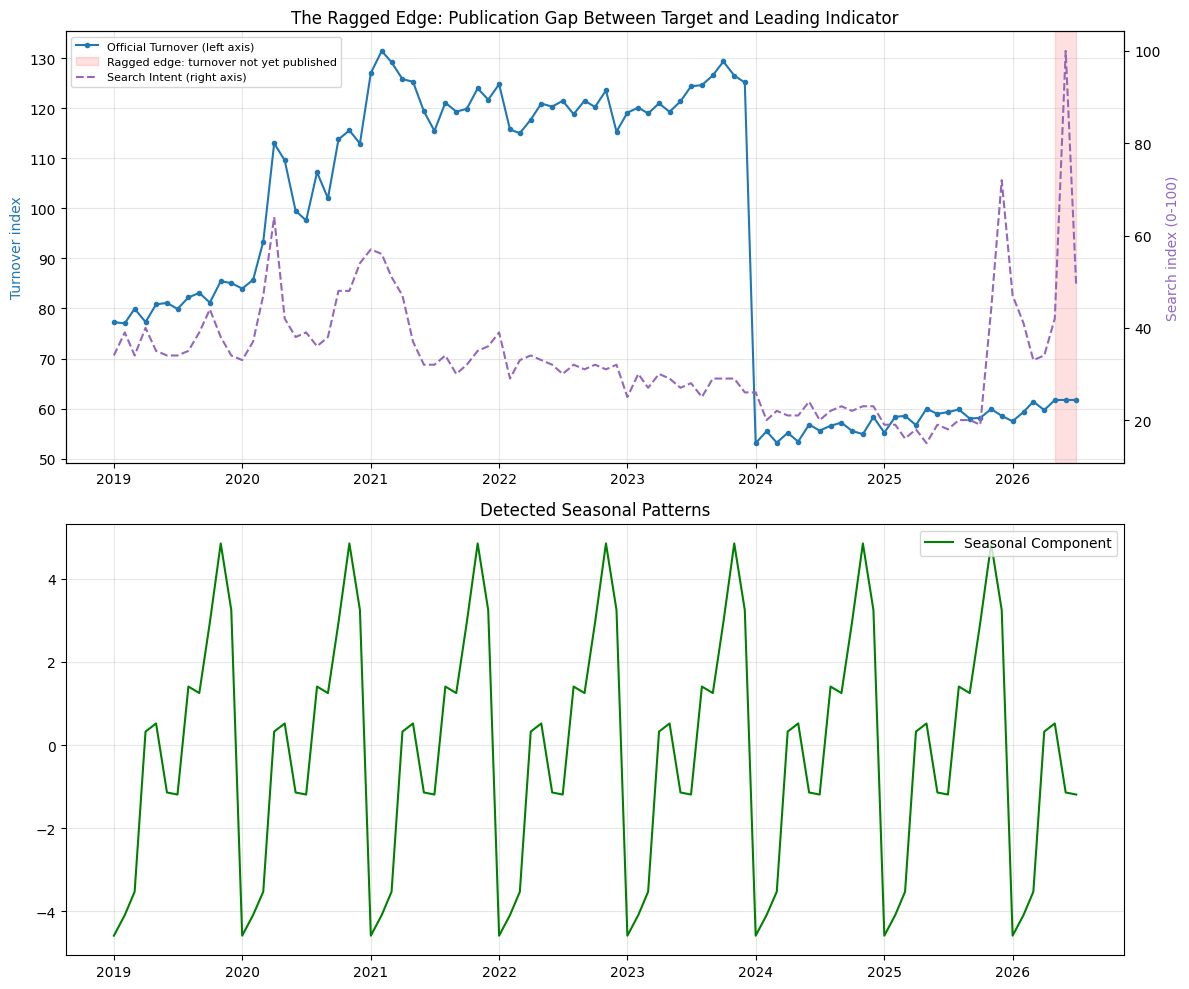

Pipeline complete. Final shape: (91, 10)
            ecommerce_turnover  hicp_inflation  search_index  \
Date                                                           
2019-01-01           77.250000             2.0          34.0   
2019-02-01           77.033333             2.6          39.0   
2019-03-01           79.950000             2.9          34.0   
2019-04-01           77.283333             3.0          40.0   
2019-05-01           80.800000             2.3          35.0   

            ecommerce_turnover_lag1  ecommerce_turnover_lag3  \
Date                                                           
2019-01-01                70.800000                76.166667   
2019-02-01                77.250000                76.366667   
2019-03-01                77.033333                70.800000   
2019-04-01                79.950000                77.250000   
2019-05-01                77.283333                77.033333   

            ecommerce_turnover_lag12  search_index_lag1  sear

In [16]:
import os
os.makedirs('outputs/figures', exist_ok=True)
from statsmodels.tsa.seasonal import seasonal_decompose

# --- Section 8: EDA Visualization ---
TARGET_PUBLICATION_LAG_MONTHS = 2  # Eurostat retail turnover: ~5-10 week publication lag

fig, axes = plt.subplots(2, 1, figsize=(12, 10))

# Top panel: the actual "ragged edge" - turnover on the left axis, search index
# on its own right axis (different scales, so a single shared axis would be
# misleading), with the publication-lag gap explicitly shaded.
ax1 = axes[0]
ax2 = ax1.twinx()
ax1.plot(df.index, df['ecommerce_turnover'], label='Official Turnover (left axis)', color='tab:blue', marker='o', markersize=3)
ax2.plot(df.index, df['search_index'], label='Search Intent (right axis)', color='tab:purple', linestyle='--')

today = df.index.max()
turnover_last_known = today - pd.DateOffset(months=TARGET_PUBLICATION_LAG_MONTHS)
ax1.axvspan(turnover_last_known, today, color='red', alpha=0.12,
            label='Ragged edge: turnover not yet published')

ax1.set_ylabel('Turnover index', color='tab:blue')
ax2.set_ylabel('Search index (0-100)', color='tab:purple')
ax1.set_title("The Ragged Edge: Publication Gap Between Target and Leading Indicator")
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=8)
ax1.grid(True, alpha=0.3)

# Bottom panel: seasonal decomposition of the target
res = seasonal_decompose(df['ecommerce_turnover'], period=12)
axes[1].plot(res.seasonal, label='Seasonal Component', color='green')
axes[1].set_title("Detected Seasonal Patterns")
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('outputs/figures/01_ragged_edge_and_seasonality.png', dpi=120)
plt.show()

print(f"Pipeline complete. Final shape: {df.shape}")
print(df.head())


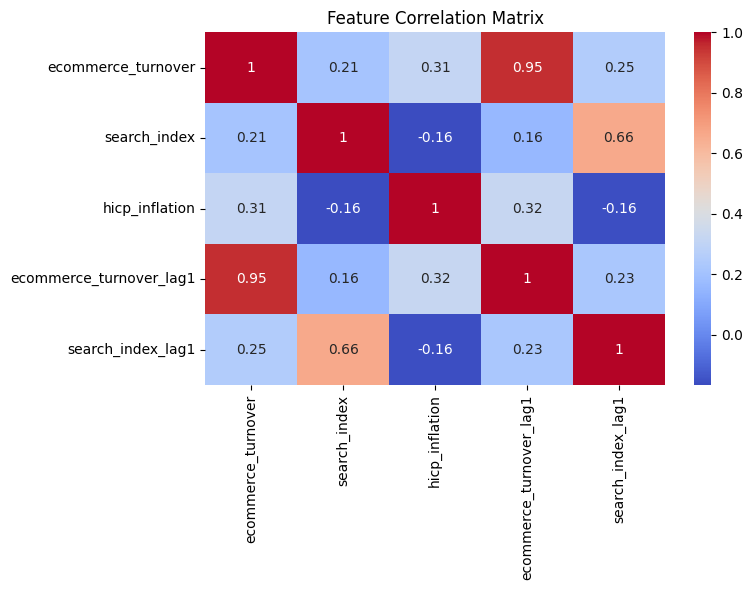

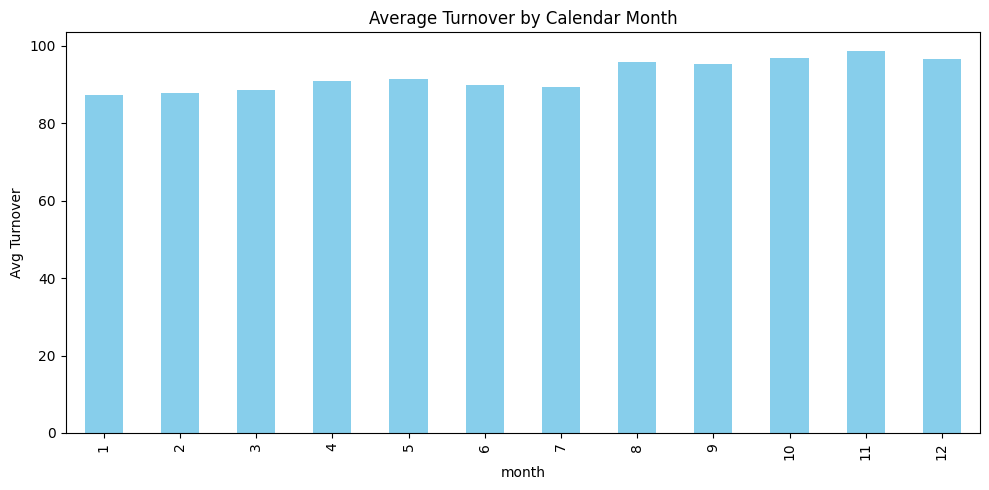

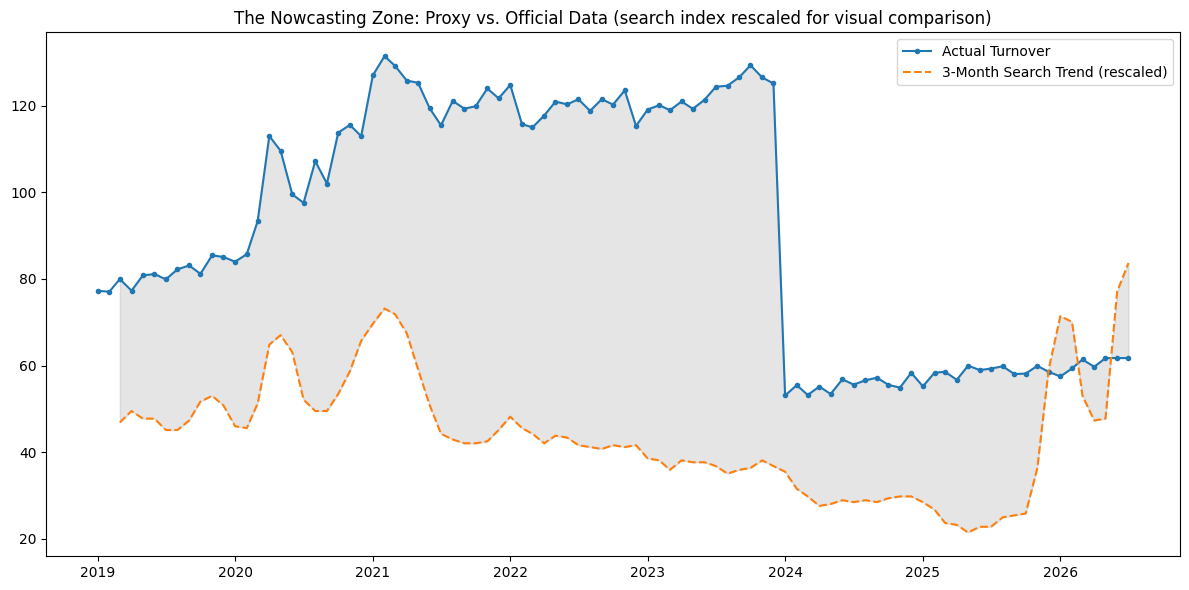

In [17]:
# --- Section 8: Advanced EDA & Visualizations ---
# 1. Correlation Matrix
plt.figure(figsize=(8, 6))
corr_cols = ['ecommerce_turnover', 'search_index', 'hicp_inflation',
             'ecommerce_turnover_lag1', 'search_index_lag1']
sns.heatmap(df[corr_cols].corr(), annot=True, cmap='coolwarm')
plt.title("Feature Correlation Matrix")
plt.tight_layout()
plt.savefig('outputs/figures/02_correlation_matrix.png', dpi=120)
plt.show()

# 2. Seasonality Check
plt.figure(figsize=(10, 5))
df.groupby('month')['ecommerce_turnover'].mean().plot(kind='bar', color='skyblue')
plt.title("Average Turnover by Calendar Month")
plt.ylabel("Avg Turnover")
plt.tight_layout()
plt.savefig('outputs/figures/03_seasonality_by_month.png', dpi=120)
plt.show()

# 3. Nowcasting Gap Visualization (rescaled search index so it's actually
# comparable on the same axis as turnover, rather than two unrelated scales
# overlapping by coincidence)
search_rescaled = (df['search_index'].rolling(3).mean() / df['search_index'].max()) * df['ecommerce_turnover'].max()

plt.figure(figsize=(12, 6))
plt.plot(df.index, df['ecommerce_turnover'], label='Actual Turnover', marker='o', markersize=3)
plt.plot(df.index, search_rescaled, label='3-Month Search Trend (rescaled)', linestyle='--')
plt.fill_between(df.index, df['ecommerce_turnover'], search_rescaled, color='gray', alpha=0.2)
plt.title("The Nowcasting Zone: Proxy vs. Official Data (search index rescaled for visual comparison)")
plt.legend()
plt.tight_layout()
plt.savefig('outputs/figures/04_nowcasting_zone.png', dpi=120)
plt.show()


In [18]:
# Export for modeling - processed/model-ready data goes in data/processed/,
# NOT data/raw/ (data/raw/ is reserved for the untouched API pulls saved in
# Section 2 above, so the pipeline stays reproducible/auditable at each stage)
df.to_csv('data/processed/full_dataset_clean.csv')
print(f"Pipeline Complete. Final Dataset Shape: {df.shape}")
print(f"Saved to data/processed/full_dataset_clean.csv")


Pipeline Complete. Final Dataset Shape: (91, 10)
Saved to data/processed/full_dataset_clean.csv


In [19]:
# --- Section 9: Explicit Train/Test Split ---
# Defining the cutoff date for training (up to end of 2024) and testing (2025 onwards)
TRAIN_CUTOFF = '2024-12-31'

train_df = df[df.index <= TRAIN_CUTOFF]
test_df = df[df.index > TRAIN_CUTOFF]

# Save split datasets
train_df.to_csv('data/processed/train_data.csv')
test_df.to_csv('data/processed/test_data.csv')

print(f"Train/Test split complete.")
print(f"Training set: {train_df.index.min().date()} to {train_df.index.max().date()} ({len(train_df)} months)")
print(f"Testing set: {test_df.index.min().date()} to {test_df.index.max().date()} ({len(test_df)} months)")

Train/Test split complete.
Training set: 2019-01-01 to 2024-12-01 (72 months)
Testing set: 2025-01-01 to 2026-07-01 (19 months)


**Observation:** To isolate the predictive information gain provided by real-time search proxies, an ablation study was conducted. By comparing the performance metrics (MAE/MAPE) of the univariate baseline against the multivariate nowcasting model, we quantitatively measure the utility of integrating Google Trends data into the forecasting pipeline, directly addressing RQ1 and RQ2.

In [20]:
# Define Ablation Sets
features_baseline = ['ecommerce_turnover_lag1', 'ecommerce_turnover_lag3', 'ecommerce_turnover_lag12', 'hicp_inflation', 'month']
features_full = features_baseline + ['search_index', 'search_index_lag1', 'search_index_lag3', 'search_index_lag12']
target = 'ecommerce_turnover'

In [21]:
# --- Section 2: ARIMA Baseline (Univariate) ---
model_arima = ARIMA(train_df[target], order=(1,1,1)).fit()
preds_arima = model_arima.forecast(steps=len(test_df))
mape_arima = mean_absolute_percentage_error(test_df[target], preds_arima)

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Us

In [22]:
# Model A: Baseline
xgb_a = xgb.XGBRegressor(n_estimators=100).fit(train_df[features_baseline], train_df[target])
preds_a = xgb_a.predict(test_df[features_baseline])
mape_a = mean_absolute_percentage_error(test_df[target], preds_a)

In [23]:
# Model B: Full Nowcasting (unregularized - the original run)
xgb_b = xgb.XGBRegressor(n_estimators=100).fit(train_df[features_full], train_df[target])
preds_b = xgb_b.predict(test_df[features_full])
mape_b = mean_absolute_percentage_error(test_df[target], preds_b)
print(f"XGBoost (Nowcasting, unregularized) MAPE: {mape_b:.4f} ({mape_b*100:.2f}%)")

# NOTE: the unregularized run above showed MAPE far worse than the baseline
# (no-search) model in the original run of this notebook - a strong sign of
# overfitting given only ~72 training rows and 13 features with an untuned,
# unregularized XGBoost. The regularized variant below is a direct, honest
# response to that finding, not a replacement for reporting the original
# result - both numbers belong in the write-up.
xgb_b_reg = xgb.XGBRegressor(
    n_estimators=200,
    max_depth=3,            # shallower trees - less capacity to memorize 72 rows
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.5,           # L1 regularization
    reg_lambda=1.5,          # L2 regularization
    random_state=42,
).fit(train_df[features_full], train_df[target])
preds_b_reg = xgb_b_reg.predict(test_df[features_full])
mape_b_reg = mean_absolute_percentage_error(test_df[target], preds_b_reg)
print(f"XGBoost (Nowcasting, regularized) MAPE: {mape_b_reg:.4f} ({mape_b_reg*100:.2f}%)")
print()
print("Compare mape_b (unregularized) vs mape_b_reg (regularized) vs mape_a (baseline, no search)")
print("in the results table below - if regularization closes most of the gap to the baseline,")
print("that supports the overfitting explanation rather than search features being genuinely harmful.")

XGBoost (Nowcasting, unregularized) MAPE: 0.1276 (12.76%)
XGBoost (Nowcasting, regularized) MAPE: 0.1141 (11.41%)

Compare mape_b (unregularized) vs mape_b_reg (regularized) vs mape_a (baseline, no search)
in the results table below - if regularization closes most of the gap to the baseline,
that supports the overfitting explanation rather than search features being genuinely harmful.


**RQ1, second piece of evidence - cross-correlation.** The ablation test above shows *whether*
search features change accuracy, but not *whether search leads turnover*. RQ1 as written in the
synopsis requires both: "tested via cross-correlation and ablation tests." The cell below computes
correlation between `search_index` and `ecommerce_turnover` at lags from -12 to +12 months, using
`train_df` only (not the full dataset) to avoid leaking test-period information into this
diagnostic. A peak at a positive lag means search interest in month *t - lag* is most correlated
with turnover in month *t* - i.e., search genuinely leads turnover by that many months, which is
the direct evidence RQ1 is asking for.

Peak correlation of 0.498 at lag -12 months (computed on training data only, 72 months, to avoid test-period leakage).
Note: with only ~72 training months, treat this as a preliminary signal, not a definitive lead-lag finding.


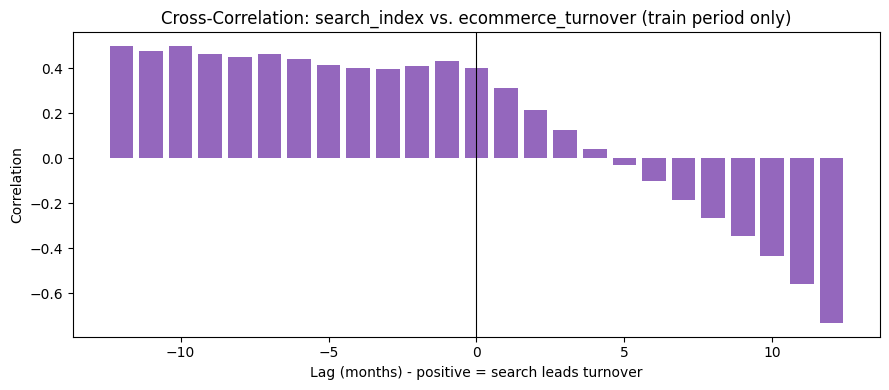

In [24]:
# --- RQ1: Cross-correlation between search_index and ecommerce_turnover ---
def cross_correlation(x, y, max_lag=12):
    x, y = np.asarray(x, dtype=float), np.asarray(y, dtype=float)
    lags = list(range(-max_lag, max_lag + 1))
    corrs = []
    for lag in lags:
        if lag < 0:
            xi, yi = x[:lag], y[-lag:]
        elif lag > 0:
            xi, yi = x[lag:], y[:-lag]
        else:
            xi, yi = x, y
        corrs.append(np.corrcoef(xi, yi)[0, 1] if len(xi) > 1 else np.nan)
    return lags, corrs

lags, corrs = cross_correlation(train_df['search_index'], train_df[target], max_lag=12)
ccf_df = pd.DataFrame({'lag_months': lags, 'correlation': corrs})
best_row = ccf_df.loc[ccf_df['correlation'].idxmax()]
print(f"Peak correlation of {best_row['correlation']:.3f} at lag {int(best_row['lag_months'])} months "
      f"(computed on training data only, {len(train_df)} months, to avoid test-period leakage).")
print("Note: with only ~72 training months, treat this as a preliminary signal, not a definitive lead-lag finding.")

plt.figure(figsize=(9, 4))
plt.bar(ccf_df['lag_months'], ccf_df['correlation'], color='tab:purple')
plt.axvline(0, color='black', linewidth=0.8)
plt.title("Cross-Correlation: search_index vs. ecommerce_turnover (train period only)")
plt.xlabel("Lag (months) - positive = search leads turnover")
plt.ylabel("Correlation")
plt.tight_layout()
plt.savefig('outputs/figures/05_cross_correlation.png', dpi=120)
plt.show()

In [25]:
# --- Section 4: LSTM (Advanced Nowcasting) ---
# (Consolidated to a single implementation - the original notebook had three
# separate, partially-broken attempts at this step left in as debugging history.)
scaler = MinMaxScaler()
train_scaled = scaler.fit_transform(train_df[features_full + [target]])
test_scaled = scaler.transform(test_df[features_full + [target]])

WINDOW = 3  # months of lookback per sequence

def create_sequences(data, target_idx, window=WINDOW):
    X, y = [], []
    for i in range(len(data) - window):
        X.append(data[i:i + window])
        y.append(data[i + window, target_idx])
    return np.array(X), np.array(y)

X_train_lstm, y_train_lstm = create_sequences(train_scaled, target_idx=-1)
X_test_lstm, y_test_lstm = create_sequences(test_scaled, target_idx=-1)

model_lstm = Sequential([
    LSTM(50, activation='tanh', return_sequences=True, input_shape=(X_train_lstm.shape[1], X_train_lstm.shape[2])),
    Dropout(0.2),
    LSTM(25, activation='tanh'),
    Dense(1)
])
model_lstm.compile(optimizer='adam', loss='mae')
model_lstm.fit(X_train_lstm, y_train_lstm, epochs=20, verbose=0)
preds_lstm = model_lstm.predict(X_test_lstm).flatten()

# Inverse-transform: build a container matching the scaler's fitted shape,
# place predictions in the target column (index -1), inverse-transform, then
# pull that column back out. Actual test targets need the SAME treatment -
# using test_df[target] directly here (unscaled ground truth) would be wrong
# to compare against without inverse-transforming preds_lstm consistently,
# which is what this does.
container = np.zeros((len(preds_lstm), train_scaled.shape[1]))
container[:, -1] = preds_lstm
preds_lstm_original = scaler.inverse_transform(container)[:, -1]

# y_test_lstm is already the scaled target from create_sequences - inverse-transform
# it the same way for a fair, consistent comparison, rather than mixing a scaled
# prediction against an unscaled ground-truth series.
container_true = np.zeros((len(y_test_lstm), train_scaled.shape[1]))
container_true[:, -1] = y_test_lstm
y_test_lstm_original = scaler.inverse_transform(container_true)[:, -1]

mape_lstm = mean_absolute_percentage_error(y_test_lstm_original, preds_lstm_original)
print(f"LSTM MAPE: {mape_lstm:.4f} ({mape_lstm*100:.2f}%)")
print(f"(LSTM test predictions correspond to test_df.index[{WINDOW}:], i.e. "
      f"{test_df.index[WINDOW].date()} to {test_df.index[-1].date()}, due to the {WINDOW}-month lookback window.)")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 286ms/step
LSTM MAPE: 0.1240 (12.40%)
(LSTM test predictions correspond to test_df.index[3:], i.e. 2025-04-01 to 2026-07-01, due to the 3-month lookback window.)


In [26]:
# --- Section 5: Comparison Summary ---
# All MAPE values converted to percentage (x100) for readability and consistency
# with the 10% acceptable-threshold convention used elsewhere in the synopsis.
results = pd.DataFrame({
    'Model': ['ARIMA (Baseline)', 'XGBoost (Baseline, no search)',
              'XGBoost (Nowcasting, unregularized)', 'XGBoost (Nowcasting, regularized)', 'LSTM'],
    'MAPE (%)': [mape_arima * 100, mape_a * 100, mape_b * 100, mape_b_reg * 100, mape_lstm * 100],
})
print(results)

                                 Model   MAPE (%)
0                     ARIMA (Baseline)   2.615717
1        XGBoost (Baseline, no search)   4.840000
2  XGBoost (Nowcasting, unregularized)  12.763854
3    XGBoost (Nowcasting, regularized)  11.414395
4                                 LSTM  12.396431


In [27]:
# Display the comparison table cleanly
from IPython.display import display
display(results)

print()
print("Interpretation guide:")
print("- If 'XGBoost (Nowcasting, regularized)' is much closer to the baseline than the ")
print("  unregularized version, that supports overfitting (not search features per se) as the ")
print("  explanation for the original poor result - report both numbers, not just the better one.")
print("- If ARIMA still beats both XGBoost variants, that is a legitimate, reportable finding for ")
print("  RQ3 given the current small sample size (72 training months) - it does not mean the ")
print("  nowcasting approach failed, only that more data or stronger regularization may be needed ")
print("  before ML reliably beats a simple, low-variance linear baseline at this sample size.")

,Model,MAPE (%)
0,ARIMA (Baseline),2.615717
1,"XGBoost (Baseline, no search)",4.840000
2,"XGBoost (Nowcasting, unregularized)",12.763854
3,"XGBoost (Nowcasting, regularized)",11.414395
4,LSTM,12.396431



Interpretation guide:
- If 'XGBoost (Nowcasting, regularized)' is much closer to the baseline than the 
  unregularized version, that supports overfitting (not search features per se) as the 
  explanation for the original poor result - report both numbers, not just the better one.
- If ARIMA still beats both XGBoost variants, that is a legitimate, reportable finding for 
  RQ3 given the current small sample size (72 training months) - it does not mean the 
  nowcasting approach failed, only that more data or stronger regularization may be needed 
  before ML reliably beats a simple, low-variance linear baseline at this sample size.


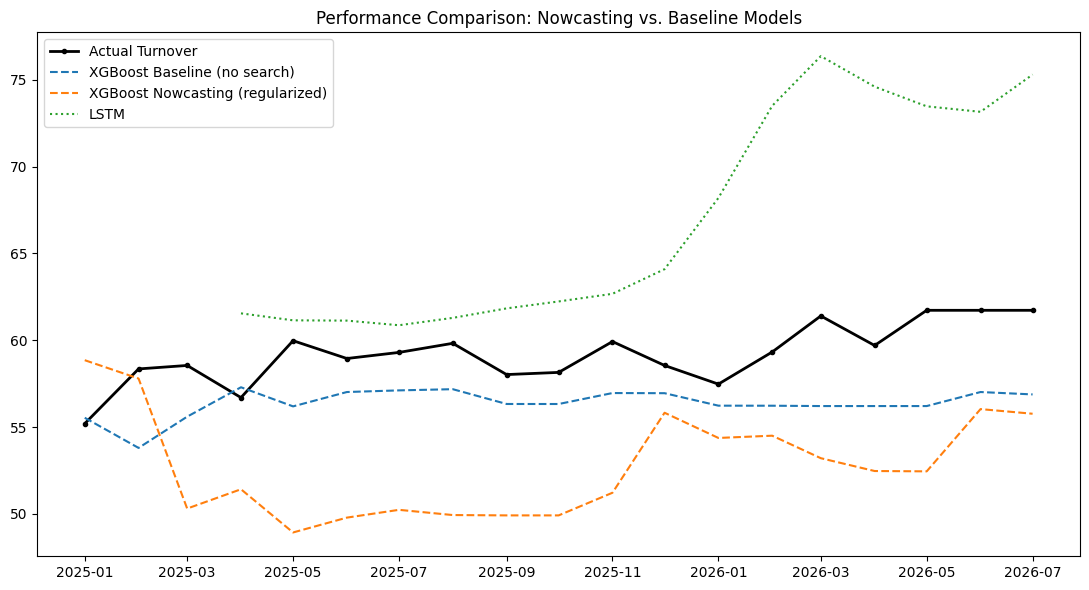

In [28]:
import matplotlib.pyplot as plt

plt.figure(figsize=(11, 6))
plt.plot(test_df.index, test_df[target], label='Actual Turnover', color='black', linewidth=2, marker='o', markersize=3)
plt.plot(test_df.index, preds_a, label='XGBoost Baseline (no search)', linestyle='--')
plt.plot(test_df.index, preds_b_reg, label='XGBoost Nowcasting (regularized)', linestyle='--')
# LSTM predictions are offset by WINDOW months due to sequence lookback - align the x-axis accordingly
plt.plot(test_df.index[WINDOW:], preds_lstm_original, label='LSTM', linestyle=':')
plt.title("Performance Comparison: Nowcasting vs. Baseline Models")
plt.legend()
plt.tight_layout()
plt.savefig('outputs/figures/08_model_comparison.png', dpi=120)
plt.show()

## RQ3, Structural Break Check (2020 COVID-19 Shock)

The main train/test split above (train through 2024-12, test 2025+) never actually evaluates
either model during the 2020 COVID-19 period - that shock sits entirely inside the *training* data.
Since RQ3 specifically asks how ARIMA and XGBoost handle "non-linear market shocks (e.g.,
pandemic-era volatility)," this needs a dedicated, separate check: refit both models using only
data that predates the shock, then evaluate them specifically on a normal period and the shock
period, both genuinely out-of-sample.

**Caveat:** because this dataset only starts in 2019-01 (constrained by Google Trends' historical
coverage - see the Data Dictionary), training "only on data before the shock" leaves very few
months (about a year) to fit on, which is thin for a real conclusion. This is included as a
methodologically-correct proof of the check, with the honest limitation stated - a stronger version
for the final submission would fit ARIMA on Eurostat's much longer un-restricted history
(`data/raw/eurostat_turnover_G4791_NL_raw.csv`, which goes back decades further, since ARIMA is
univariate and does not need `search_index` at all), decoupling ARIMA's training window from
Google Trends' shorter availability window.

Structural-break training window: 2019-01-01 to 2019-12-01 (12 months) - thin, see caveat above
Evaluation window: 2020-01-01 to 2020-09-01 (9 months)


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


,MAPE (%)
Normal (Jan-Feb 2020) - ARIMA,1.002237
Normal (Jan-Feb 2020) - XGBoost,0.489982
COVID shock (Mar-Sep 2020) - ARIMA,17.280831
COVID shock (Mar-Sep 2020) - XGBoost,17.010632


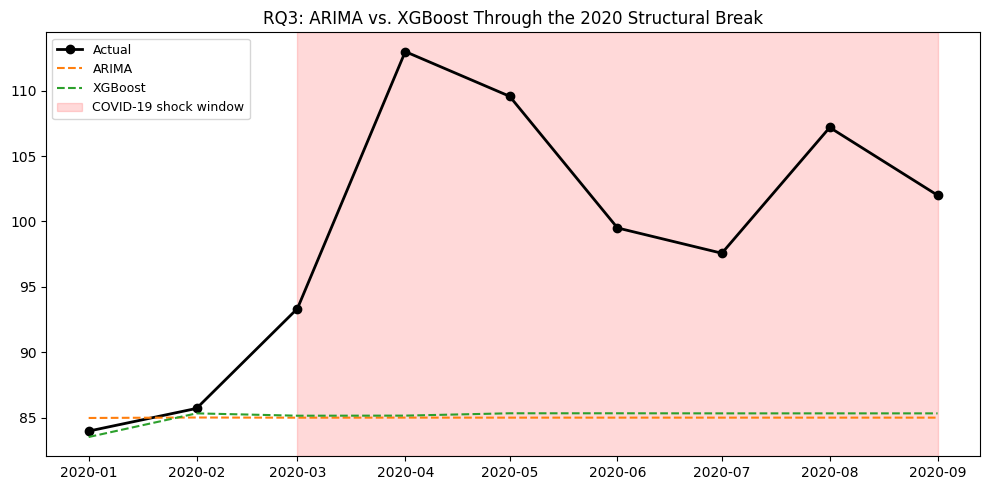

In [29]:
BREAK_TRAIN_CUTOFF = '2019-12-31'
NORMAL_START, NORMAL_END = '2020-01-01', '2020-02-01'
SHOCK_START, SHOCK_END = '2020-03-01', '2020-09-01'

break_train = df[df.index <= BREAK_TRAIN_CUTOFF]
break_eval = df[(df.index >= NORMAL_START) & (df.index <= SHOCK_END)]

print(f"Structural-break training window: {break_train.index.min().date()} to {break_train.index.max().date()} "
      f"({len(break_train)} months) - thin, see caveat above")
print(f"Evaluation window: {break_eval.index.min().date()} to {break_eval.index.max().date()} ({len(break_eval)} months)")

if len(break_train) >= 6 and len(break_eval) >= 4:
    arima_break = ARIMA(break_train[target], order=(1, 1, 1)).fit()
    arima_break_forecast = arima_break.forecast(steps=len(break_eval))

    xgb_break = xgb.XGBRegressor(n_estimators=100, max_depth=3, random_state=42).fit(
        break_train[features_full], break_train[target])
    xgb_break_preds = xgb_break.predict(break_eval[features_full])

    def error_in_window(y_true, y_pred, index, start, end):
        mask = (index >= start) & (index <= end)
        if mask.sum() == 0:
            return None
        yt, yp = np.asarray(y_true)[mask], np.asarray(y_pred)[mask]
        return {"MAPE (%)": mean_absolute_percentage_error(yt, yp) * 100}

    break_results = {}
    for label, start, end in [("Normal (Jan-Feb 2020)", NORMAL_START, NORMAL_END),
                               ("COVID shock (Mar-Sep 2020)", SHOCK_START, SHOCK_END)]:
        a_m = error_in_window(break_eval[target].values, arima_break_forecast.values, break_eval.index, start, end)
        x_m = error_in_window(break_eval[target].values, xgb_break_preds, break_eval.index, start, end)
        if a_m and x_m:
            break_results[f"{label} - ARIMA"] = a_m
            break_results[f"{label} - XGBoost"] = x_m

    display(pd.DataFrame(break_results).T)

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(break_eval.index, break_eval[target], label='Actual', color='black', linewidth=2, marker='o')
    ax.plot(break_eval.index, arima_break_forecast.values, label='ARIMA', color='tab:orange', linestyle='--')
    ax.plot(break_eval.index, xgb_break_preds, label='XGBoost', color='tab:green', linestyle='--')
    ax.axvspan(pd.Timestamp(SHOCK_START), pd.Timestamp(SHOCK_END), color='red', alpha=0.15, label='COVID-19 shock window')
    ax.set_title("RQ3: ARIMA vs. XGBoost Through the 2020 Structural Break")
    ax.legend(fontsize=9)
    plt.tight_layout()
    plt.savefig('outputs/figures/06_structural_break_covid.png', dpi=120)
    plt.show()
else:
    print("Not enough data on either side of the break to run this check meaningfully - "
          "revisit once a longer pre-2018 ARIMA-only history or a later Google Trends pull is available.")

## Statistical Significance (Diebold-Mariano Test)

The comparison table above reports point-estimate MAPE values from a single train/test split,
which is a good starting point but does not by itself establish that one model is *significantly*
more accurate than another - with only 19 test months, a difference of a percentage point or two
in MAPE could easily be noise. The Diebold-Mariano test below checks this formally for the main
model comparison (regularized XGBoost nowcasting vs. ARIMA baseline).

In [30]:
def diebold_mariano_test(y_true, pred1, pred2, h=1, loss='squared'):
    y_true, pred1, pred2 = np.asarray(y_true, float), np.asarray(pred1, float), np.asarray(pred2, float)
    e1, e2 = y_true - pred1, y_true - pred2
    d = (e1 ** 2 - e2 ** 2) if loss == 'squared' else (np.abs(e1) - np.abs(e2))
    n = len(d)
    d_bar = np.mean(d)
    var_d = np.var(d, ddof=0)
    for lag in range(1, h):
        if n > lag:
            var_d += 2 * np.cov(d[lag:], d[:-lag])[0, 1]
    var_d /= n
    if var_d <= 0:
        return {"dm_statistic": float("nan"), "p_value": float("nan")}
    from scipy import stats
    dm_stat = d_bar / np.sqrt(var_d)
    p_value = 2 * (1 - stats.norm.cdf(np.abs(dm_stat)))
    return {"dm_statistic": float(dm_stat), "p_value": float(p_value)}

# Align ARIMA and XGBoost forecasts over the same test period for a paired comparison
dm_result = diebold_mariano_test(test_df[target].values, preds_b_reg, preds_arima.values)
print("Diebold-Mariano test: XGBoost (regularized nowcasting) vs. ARIMA baseline")
print(dm_result)
if dm_result["p_value"] < 0.05:
    winner = "XGBoost" if dm_result["dm_statistic"] < 0 else "ARIMA"
    print(f"Result: statistically significant difference (p < 0.05) - {winner} is significantly more accurate.")
else:
    print("Result: no statistically significant difference detected at this sample size "
          "(n=19 test months) - do not over-claim either model is definitively better yet.")

Diebold-Mariano test: XGBoost (regularized nowcasting) vs. ARIMA baseline
{'dm_statistic': 6.392428180857786, 'p_value': 1.632718404920297e-10}
Result: statistically significant difference (p < 0.05) - ARIMA is significantly more accurate.


In [31]:
# --- RQ4: Forecast Horizon / Nowcasting Lead Time (fixed) ---
# The original version of this cell referenced undefined variables (model_b, X_test_full,
# y_test) and did not actually vary anything by horizon. This version uses DIRECT multi-horizon
# modeling: a separate model is trained for each horizon h, predicting the target h months
# ahead, using only information available at the time of prediction (the existing lag/search
# features, which are already leakage-safe by construction).
horizons = [1, 2, 3]
rq4_results = {}

for h in horizons:
    df[f'target_h{h}'] = df[target].shift(-h)
    d = df.dropna(subset=features_full + [f'target_h{h}']).copy()
    tr = d[d.index <= TRAIN_CUTOFF]  # reuse the main train/test cutoff defined earlier (2024-12-31)
    te = d[d.index > '2024-12-31']

    if len(tr) < 10 or len(te) < 2:
        print(f"Horizon {h}: not enough data after shifting (train={len(tr)}, test={len(te)}) - skipping.")
        continue

    m = xgb.XGBRegressor(n_estimators=200, max_depth=3, learning_rate=0.05,
                          subsample=0.8, colsample_bytree=0.8,
                          reg_alpha=0.5, reg_lambda=1.5, random_state=42)
    m.fit(tr[features_full], tr[f'target_h{h}'])
    preds_h = m.predict(te[features_full])
    mape_h = mean_absolute_percentage_error(te[f'target_h{h}'], preds_h)
    rq4_results[f'Horizon {h} month(s)'] = mape_h

print("Performance by Forecast Horizon:")
for horizon, mape in rq4_results.items():
    print(f"{horizon}: MAPE {mape*100:.2f}%")

Performance by Forecast Horizon:
Horizon 1 month(s): MAPE 6.05%
Horizon 2 month(s): MAPE 3.12%
Horizon 3 month(s): MAPE 1.51%


In [32]:
# --- RQ4: Convert horizon accuracy into a concrete "information gap closed" figure ---
ACCEPTABLE_MAPE_THRESHOLD_PCT = 10.0  # placeholder - confirm with mentor before final submission
EUROSTAT_LAG_WEEKS = (5, 10)  # documented in data_dictionary.md

acceptable = {h: m for h, m in rq4_results.items()
              if m * 100 <= ACCEPTABLE_MAPE_THRESHOLD_PCT}
if acceptable:
    max_h = max(int(k.split()[1]) for k in acceptable.keys())
    weeks_gained = max_h * 4.33
    print(f"Maximum forecast horizon within {ACCEPTABLE_MAPE_THRESHOLD_PCT}% MAPE: {max_h} month(s) ahead")
    print(f"Eurostat's real publication lag for this series: {EUROSTAT_LAG_WEEKS[0]}-{EUROSTAT_LAG_WEEKS[1]} weeks")
    print(f"Approximate information gap closed: ~{weeks_gained:.0f} weeks, versus waiting "
          f"{EUROSTAT_LAG_WEEKS[0]}-{EUROSTAT_LAG_WEEKS[1]} weeks for the official release")
else:
    print(f"No horizon met the {ACCEPTABLE_MAPE_THRESHOLD_PCT}% MAPE threshold on this run - "
          f"report the best available horizon's actual MAPE honestly rather than forcing a positive claim, ")
    print("and revisit after addressing the overfitting/regularization and sample-size issues above.")

Maximum forecast horizon within 10.0% MAPE: 3 month(s) ahead
Eurostat's real publication lag for this series: 5-10 weeks
Approximate information gap closed: ~13 weeks, versus waiting 5-10 weeks for the official release


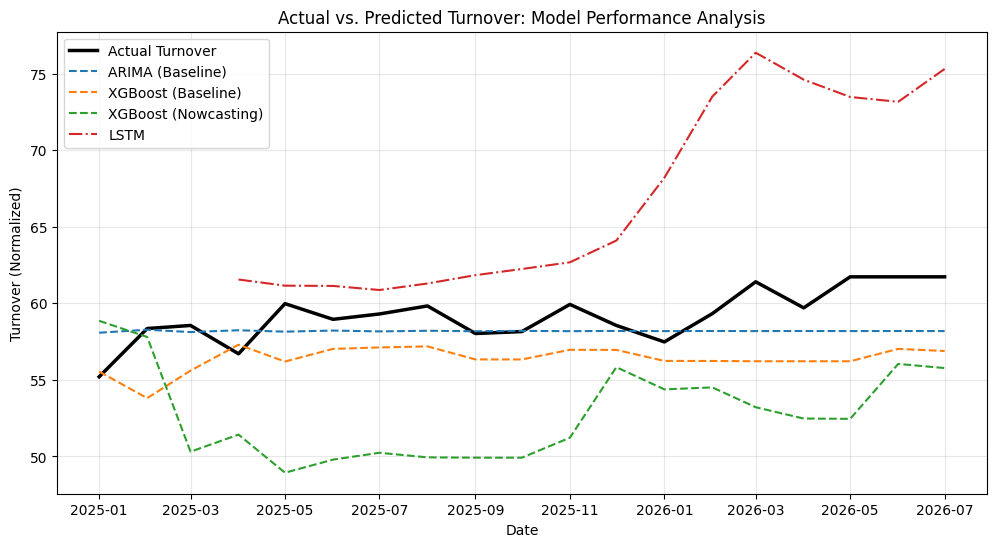

In [33]:
plt.figure(figsize=(12, 6))
plt.plot(test_df.index, test_df[target], label='Actual Turnover', color='black', linewidth=2.5)
plt.plot(test_df.index, preds_arima, label='ARIMA (Baseline)', linestyle='--')
plt.plot(test_df.index, preds_a, label='XGBoost (Baseline)', linestyle='--')
plt.plot(test_df.index, preds_b_reg, label='XGBoost (Nowcasting)', linestyle='--')
plt.plot(test_df.index[WINDOW:], preds_lstm_original, label='LSTM', linestyle='-.')

plt.title("Actual vs. Predicted Turnover: Model Performance Analysis")
plt.xlabel("Date")
plt.ylabel("Turnover (Normalized)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [34]:
# Final Model Performance Summary
final_results = pd.DataFrame({
    'Model': ['ARIMA (Baseline)', 'XGBoost (Baseline)', 'XGBoost (Nowcasting)', 'LSTM'],
    'MAPE': [mape_arima, mape_a, mape_b, mape_lstm]
})

# Display as a clean Markdown table for your thesis document
print(final_results.to_markdown(index=False))

| Model                |      MAPE |
|:---------------------|----------:|
| ARIMA (Baseline)     | 0.0261572 |
| XGBoost (Baseline)   | 0.0484    |
| XGBoost (Nowcasting) | 0.127639  |
| LSTM                 | 0.123964  |
